## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import random

In [2]:
real_or_simulated = 'real' #simulated / real / all
keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
remove_outliers = False
augmentation = True

if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'
    
if remove_outliers:
    outliers = 'outliers_removed'
else:
    outliers = 'outliers_present'

In [3]:
outliers_indices = {
    'simulated': list(range(1035, 1050)) + list(range(1020, 1035)),
    'real': list(range(2370, 2385))
                    }

## Loading the data

In [4]:
data_path = '../data/DANE.xlsx'

In [5]:
df = pd.ExcelFile(data_path)
if real_or_simulated == 'simulated':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
elif real_or_simulated == 'real':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
elif real_or_simulated == 'all':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list) #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

In [6]:
if augmentation:
    inks_df_sim = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df_sim = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
    inks_df_sim = inks_df_sim.reset_index(drop=False)
    inds_df_sim = inds_df_sim.reset_index(drop=False)
    inDKs_df_sim = inds_df_sim.join(inks_df_sim, how='inner', rsuffix='_inks', lsuffix='_inds')
    inDKs_df_sim.dropna(inplace=True)

## Preprocessing

### Joining corresponding samples from inds and inks into one table

In [7]:
inks_df = inks_df.reset_index(drop=False)

In [8]:
inds_df = inds_df.reset_index(drop=False)

In [9]:
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inks', lsuffix='_inds')

In [10]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df[['nazwa próbki_inds', 'nazwa próbki_inks']][
#                 (inDKs_df['nazwa próbki_inds'].apply(
#                         lambda x: x[:4]) != inDKs_df['nazwa próbki_inks'].apply(
#                                         lambda x: x[:4]))
#                                                         ])

### Removing some data

1. Let's remove rows with missing values.

In [11]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.047337278106508875

In [12]:
inDKs_df.dropna(inplace=True)

In [13]:
inDKs_df.shape

(2415, 64)

2. Let's keep only columns that we need.

In [14]:
inks_colnames = [col for col in inDKs_df.columns if (col.endswith('_inks') and 
                                                     col != 'nazwa próbki_inks'and
                                                    col != 'seria_inks' and
                                                    col != 'Fe_inks')]
inds_colnames = [col for col in inDKs_df.columns if (col.endswith('_inds') and 
                                                     col != 'nazwa próbki_inds'and
                                                    col != 'seria_inds' and
                                                    col != 'Fe_inds')]
#no iron because it's a reference element

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

If you want to keep use version with 29 numbers, just comment out the cell below.

In [15]:
inks_colnames = [
 'Al_inks',
 'S_inks',
 'Cr_inks',
 'Mn_inks',
 'Co_inks',
 'Cu_inks',
 'Zn_inks',
 'Pb_inks']

inds_colnames = [
 'Al_inds',
 'S_inds',
 'Cr_inds',
 'Mn_inds',
 'Co_inds',
 'Cu_inds',
 'Zn_inds',
 'Pb_inds']

In [16]:
inDKs_df = inDKs_df[inks_colnames + inds_colnames]

2. Let's add artificial examples: mix of real and simulated data.

In [17]:
if augmentation:
    indices_to_mix_real = random.sample(range(inDKs_df.shape[0]), int(np.floor(inDKs_df.shape[0]/4)))
    indices_to_mix_sim = random.sample(range(inDKs_df_sim.shape[0]), int(np.floor(inDKs_df.shape[0]/4)))
    indices_not_to_mix_real = list(set(range(inDKs_df.shape[0])).difference(set(indices_to_mix_real)))
    indices_not_to_mix_sim = list(set(range(inDKs_df_sim.shape[0])).difference(set(indices_to_mix_sim)))
    
    inDKs_df_not_mixed = inDKs_df.iloc[indices_not_to_mix_real]
    inDKs_df_to_mix_real = inDKs_df.iloc[indices_to_mix_real]
    inDKs_df_to_mix_sim = inDKs_df.iloc[indices_to_mix_sim]
    inDKs_df_not_mixed.reset_index(inplace=True, drop=True)
    inDKs_df_to_mix_real.reset_index(inplace=True, drop=True)
    inDKs_df_to_mix_sim.reset_index(inplace=True, drop=True)
    inDKs_df_augmented = inDKs_df_to_mix_real*0.9 + inDKs_df_to_mix_sim*0.1
    
    #inDKs_df = inDKs_df_not_mixed

### Creating features and labels matrices

In [18]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [19]:
X = np.array(inDKs_df[inds_colnames].values)
y = np.array(inDKs_df[inks_colnames].values)

if augmentation:
    X_aug = np.array(inDKs_df_augmented[inds_colnames].values)
    y_aug = np.array(inDKs_df_augmented[inks_colnames].values)

if remove_outliers:
    if real_or_simulated == 'real':
        indices_to_remove = outliers_indices['real']
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

    elif real_or_simulated == 'simulated':
        indices_to_remove = outliers_indices['simulated']
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

    elif real_or_simulated == 'all':
        indices_to_remove = outliers_indices['simulated'] + \
                            [ind + 1425 for ind in outliers_indices['real']]
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

### Normalization

In [20]:
X = (X - np.mean(X, axis=0))/np.std(X, axis=0)
y = (y - np.mean(y, axis=0))/np.std(y, axis=0)
if augmentation:
    X_aug = (X_aug - np.mean(X_aug, axis=0))/np.std(X_aug, axis=0)
    y_aug = (y_aug - np.mean(y_aug, axis=0))/np.std(y_aug, axis=0)

### Converting to tensors

In [21]:
X = torch.Tensor(X).to(device)
y = torch.Tensor(y).to(device)
if augmentation:
    X_aug = torch.Tensor(X_aug).to(device)
    y_aug = torch.Tensor(y_aug).to(device)

### Train test split, datasets, dataloaders

15 slices from the same sample should either all go to train or all go to test.

In [22]:
if keep_sample_together:
    indices = list(range(int(X.shape[0]/15)))
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    ind_train_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_train]
    ind_train_all = [x for l in ind_train_all for x in l]
    ind_val_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_val]
    ind_val_all = [x for l in ind_val_all for x in l]
    ind_test_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_test]
    ind_test_all = [x for l in ind_test_all for x in l]

else:
    indices = list(range(int(X.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)

In [23]:
partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}

In [24]:
X_train = X[partition['train']]
y_train = y[partition['train']]

X_val = X[partition['val']]
y_val = y[partition['val']]

X_test = X[partition['test']]
y_test = y[partition['test']]

In [25]:
if augmentation:
    X_train = torch.cat([X_train, X_aug])
    y_train = torch.cat([y_train, y_aug])

### Dataset

In [26]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [27]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [28]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=True)

## Building neural network

In [29]:
input_size = X_train.shape[1]

For now, we keep only use very simple neural network. The layers are lineaer, each has the same number of neurons equal to the size of input (and, at the same time, size of output).

In [30]:
class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size))
    def forward(self, x):
        return self.seq(x)

## Training

In [31]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=8, bias=True)
  )
)


In [32]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

In [33]:
weights = torch.tensor([1/2,1/4,1/8,1/40,1/40,1/40,1/40,1/40]).unsqueeze(1).to(device)

class CustomLoss(nn.Module):
    def __init__(self, weights=weights):
        super(CustomLoss, self).__init__()
        self.weights = weights
        assert weights.shape[1] == 1

    def forward(self, outputs, targets):
        inner_loss = nn.L1Loss(reduction='none')
        res = inner_loss(outputs, targets)
        res = torch.mm(res, self.weights)
        res = res.mean(axis=0)
#         inner_loss_to_compare = nn.L1Loss(reduction='mean')
#         assert torch.isclose(inner_loss_to_compare(outputs, targets), res)
        return res

In [34]:
# loss = F.l1_loss(torch.t(torch.mul(torch.t(forecast), 
#                                            torch.tensor(weight,dtype=torch.float).to(DEVICE))) ,
#                          torch.t(torch.mul(torch.t(torch.tensor(target,dtype=torch.float).to(DEVICE)), 
#                                            torch.tensor(weight,dtype=torch.float).to(DEVICE))),reduction='mean')
# loss.backward()
# params.append(net.parameters())
# optimiser.step()

In [35]:
EPOCHS = 5000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 0.5207968666439965 test 0.5294262880833499
EPOCH 2:
LOSS train 0.5185866568769727 test 0.5254073571992217
EPOCH 3:
LOSS train 0.5166712743895394 test 0.5215197911883239
EPOCH 4:
LOSS train 0.5097450798466092 test 0.5177277769145264
EPOCH 5:
LOSS train 0.5091890196005503 test 0.5140621640389751
EPOCH 6:
LOSS train 0.5028794606526693 test 0.5104543891413365
EPOCH 7:
LOSS train 0.49846574664115906 test 0.506948201059061
EPOCH 8:
LOSS train 0.49811924071539015 test 0.5035109700901168
EPOCH 9:
LOSS train 0.4925969271432786 test 0.5001604638484695
EPOCH 10:
LOSS train 0.4910120864709218 test 0.4968813649739291
EPOCH 11:
LOSS train 0.48832839869317557 test 0.4936659247701212
EPOCH 12:
LOSS train 0.48372549953914823 test 0.49053346066432957
EPOCH 13:
LOSS train 0.4812661366803305 test 0.487474642586017
EPOCH 14:
LOSS train 0.4782043397426605 test 0.48444267545921216
EPOCH 15:
LOSS train 0.4751796339239393 test 0.4814684743651692
EPOCH 16:
LOSS train 0.4703439048358372 test 

LOSS train 0.1799966228150186 test 0.1886512498220903
EPOCH 129:
LOSS train 0.18082204319181897 test 0.18822411213486645
EPOCH 130:
LOSS train 0.1808110060436385 test 0.1876437067223894
EPOCH 131:
LOSS train 0.17931162211157026 test 0.1870583978483519
EPOCH 132:
LOSS train 0.1786554299649738 test 0.18657212759663136
EPOCH 133:
LOSS train 0.17872573683659235 test 0.1861648371136568
EPOCH 134:
LOSS train 0.1766925478974978 test 0.18571366251236132
EPOCH 135:
LOSS train 0.17636688231002717 test 0.18526329337879552
EPOCH 136:
LOSS train 0.17911299814780554 test 0.18478284757314384
EPOCH 137:
LOSS train 0.18054349968830744 test 0.18449826438778213
EPOCH 138:
LOSS train 0.1777330654717627 test 0.1839555469736858
EPOCH 139:
LOSS train 0.17732768044585273 test 0.18363436969193797
EPOCH 140:
LOSS train 0.17699392352785384 test 0.18331248685428353
EPOCH 141:
LOSS train 0.17891836556650342 test 0.1829772340413376
EPOCH 142:
LOSS train 0.17600554618097486 test 0.18266817814849826
EPOCH 143:
LOSS t

LOSS train 0.16524880734227954 test 0.17059146221746416
EPOCH 253:
LOSS train 0.16376268828199023 test 0.17045400940521965
EPOCH 254:
LOSS train 0.16624386644079572 test 0.17036728109146312
EPOCH 255:
LOSS train 0.1637511718131247 test 0.17037445025356568
EPOCH 256:
LOSS train 0.16712339577220736 test 0.17021199407376056
EPOCH 257:
LOSS train 0.1649526237022309 test 0.17001466324271375
EPOCH 258:
LOSS train 0.16445674605312802 test 0.1699857486172832
EPOCH 259:
LOSS train 0.16374556046156657 test 0.1698672224692306
EPOCH 260:
LOSS train 0.16457310567299524 test 0.1696787410084058
EPOCH 261:
LOSS train 0.16452768586930774 test 0.16960700212516985
EPOCH 262:
LOSS train 0.16659875497931526 test 0.1694572258405156
EPOCH 263:
LOSS train 0.163641995262532 test 0.1694579531214977
EPOCH 264:
LOSS train 0.16512556196678252 test 0.1693272703832428
EPOCH 265:
LOSS train 0.16332089368786132 test 0.16916776065546904
EPOCH 266:
LOSS train 0.16339532605239324 test 0.16919202844980588
EPOCH 267:
LOSS 

LOSS train 0.15456834470941908 test 0.15996236599283775
EPOCH 377:
LOSS train 0.15677610962163835 test 0.16011826325049835
EPOCH 378:
LOSS train 0.1561403732214655 test 0.15986971131200067
EPOCH 379:
LOSS train 0.15618395698922022 test 0.15989395738608256
EPOCH 380:
LOSS train 0.15585162738958994 test 0.15993420558057989
EPOCH 381:
LOSS train 0.16038390355450766 test 0.1598744842630674
EPOCH 382:
LOSS train 0.1561604482786996 test 0.15978659387855304
EPOCH 383:
LOSS train 0.15773596366246542 test 0.16000512386161225
EPOCH 384:
LOSS train 0.15513947960876284 test 0.15967575105015133
EPOCH 385:
LOSS train 0.1550976261496544 test 0.15972253588639493
EPOCH 386:
LOSS train 0.15434582992678597 test 0.1598400497851473
EPOCH 387:
LOSS train 0.15427583810828982 test 0.1594902749605261
EPOCH 388:
LOSS train 0.15754025926192602 test 0.15965106293528222
EPOCH 389:
LOSS train 0.1563267314008304 test 0.15958102130741805
EPOCH 390:
LOSS train 0.1548670796411378 test 0.1595611423176885
EPOCH 391:
LOSS

LOSS train 0.15136261390788214 test 0.1548734443323922
EPOCH 502:
LOSS train 0.1512888524503935 test 0.15520037332063782
EPOCH 503:
LOSS train 0.15339369433266775 test 0.15509357171781038
EPOCH 504:
LOSS train 0.15382142648810432 test 0.15489542965466777
EPOCH 505:
LOSS train 0.15275516573871886 test 0.1549856123585817
EPOCH 506:
LOSS train 0.15242770456132435 test 0.15486836608009524
EPOCH 507:
LOSS train 0.15254353093249456 test 0.1548235319095893
EPOCH 508:
LOSS train 0.15146098321392423 test 0.15503386957243115
EPOCH 509:
LOSS train 0.15372945226374127 test 0.15500879929715278
EPOCH 510:
LOSS train 0.1521558172646023 test 0.1548768259444145
EPOCH 511:
LOSS train 0.1562728076463654 test 0.15484433629170183
EPOCH 512:
LOSS train 0.151858304582891 test 0.15479327624617434
EPOCH 513:
LOSS train 0.1530165516194843 test 0.15488134468780296
EPOCH 514:
LOSS train 0.15108350203150794 test 0.15467994043885058
EPOCH 515:
LOSS train 0.1529357074981644 test 0.15503490775800455
EPOCH 516:
LOSS t

...

LOSS train 0.12436543795324508 test 0.13060246898327987
EPOCH 4417:
LOSS train 0.12507480808666774 test 0.13041525365356704
EPOCH 4418:
LOSS train 0.12311907502866927 test 0.1303864535557465
EPOCH 4419:
LOSS train 0.12299454673415139 test 0.13040432460050774
EPOCH 4420:
LOSS train 0.12455168543826967 test 0.13036030341194282
EPOCH 4421:
LOSS train 0.12308305927685328 test 0.1302758196183706
EPOCH 4422:
LOSS train 0.1244344317487308 test 0.13036586313776471
EPOCH 4423:
LOSS train 0.12404723394484747 test 0.13046517763884571
EPOCH 4424:
LOSS train 0.1263732189933459 test 0.13043095196614632
EPOCH 4425:
LOSS train 0.1225530859969911 test 0.13043451258299513
EPOCH 4426:
LOSS train 0.12396687056337084 test 0.13053204331789975
EPOCH 4427:
LOSS train 0.12279133392231804 test 0.1305571829458587
EPOCH 4428:
LOSS train 0.12368982143345333 test 0.13027442113918639
EPOCH 4429:
LOSS train 0.12522891731489272 test 0.13034518221855995
EPOCH 4430:
LOSS train 0.12340401042075384 test 0.1304910486635383

LOSS train 0.12410285323858261 test 0.13048354788504032
EPOCH 4539:
LOSS train 0.12635217429626555 test 0.13061238483450613
EPOCH 4540:
LOSS train 0.12378603219985962 test 0.1305990934084646
EPOCH 4541:
LOSS train 0.12472019557441984 test 0.130367658514622
EPOCH 4542:
LOSS train 0.12540009121100107 test 0.13077286329587023
EPOCH 4543:
LOSS train 0.1238363120882284 test 0.13048160596178
EPOCH 4544:
LOSS train 0.12357307473818462 test 0.13049751108388877
EPOCH 4545:
LOSS train 0.12228229570956457 test 0.13061081110663697
EPOCH 4546:
LOSS train 0.12426620367027465 test 0.13032159644061425
EPOCH 4547:
LOSS train 0.12454687520152047 test 0.13040971935882886
EPOCH 4548:
LOSS train 0.12441093793937139 test 0.13051683027258695
EPOCH 4549:
LOSS train 0.12250409470427603 test 0.13037552165955027
EPOCH 4550:
LOSS train 0.12394865460339047 test 0.13033990367502746
EPOCH 4551:
LOSS train 0.12277335744528543 test 0.13049227403338004
EPOCH 4552:
LOSS train 0.12477842824799674 test 0.130507214121158
E

LOSS train 0.12245953260433107 test 0.13042782377702325
EPOCH 4661:
LOSS train 0.12345568161635172 test 0.1307192600580939
EPOCH 4662:
LOSS train 0.12320457931075778 test 0.13060382835462875
EPOCH 4663:
LOSS train 0.12458837848334085 test 0.1304050849154823
EPOCH 4664:
LOSS train 0.12340342501799266 test 0.13059929342589516
EPOCH 4665:
LOSS train 0.12374231112854821 test 0.13051129438515222
EPOCH 4666:
LOSS train 0.12277523463680631 test 0.13053329721648502
EPOCH 4667:
LOSS train 0.12518983298823946 test 0.13045169163580142
EPOCH 4668:
LOSS train 0.12370827616680236 test 0.13078379686671168
EPOCH 4669:
LOSS train 0.12478237812008176 test 0.1304383356486665
EPOCH 4670:
LOSS train 0.1251180920572508 test 0.13041672327576925
EPOCH 4671:
LOSS train 0.1228267742054803 test 0.13056530074388037
EPOCH 4672:
LOSS train 0.12431552438508897 test 0.13053883485376497
EPOCH 4673:
LOSS train 0.12396247862350374 test 0.1304058013406754
EPOCH 4674:
LOSS train 0.12376197746821813 test 0.1304935189368932

LOSS train 0.1257627471571877 test 0.13050969328546191
EPOCH 4783:
LOSS train 0.1249885605204673 test 0.13054516158060905
EPOCH 4784:
LOSS train 0.12434456887699309 test 0.13057839656036585
EPOCH 4785:
LOSS train 0.12351026918206896 test 0.1303397348964313
EPOCH 4786:
LOSS train 0.12339405715465546 test 0.13042046122761988
EPOCH 4787:
LOSS train 0.12596959265924634 test 0.1304128239910826
EPOCH 4788:
LOSS train 0.12441313302233106 test 0.13035090659180074
EPOCH 4789:
LOSS train 0.12207979283162526 test 0.130406610417039
EPOCH 4790:
LOSS train 0.12268003360146568 test 0.13040535863272953
EPOCH 4791:
LOSS train 0.12442869551125027 test 0.13061081589340362
EPOCH 4792:
LOSS train 0.12545499205589294 test 0.1304326128237736
EPOCH 4793:
LOSS train 0.12298837481510072 test 0.13050415662578144
EPOCH 4794:
LOSS train 0.1224977235708918 test 0.1304229042323125
EPOCH 4795:
LOSS train 0.1223177636663119 test 0.13047849423662752
EPOCH 4796:
LOSS train 0.12370715361265909 test 0.1304784313983845
EPO

LOSS train 0.12257855172668185 test 0.13056184677407146
EPOCH 4905:
LOSS train 0.12298375616470973 test 0.1303577740410609
EPOCH 4906:
LOSS train 0.12615402858881725 test 0.13038871967181656
EPOCH 4907:
LOSS train 0.12549998611211777 test 0.13031853176556976
EPOCH 4908:
LOSS train 0.12461831030391511 test 0.13030261587540526
EPOCH 4909:
LOSS train 0.12463255368527912 test 0.13033284198812847
EPOCH 4910:
LOSS train 0.12312573655730202 test 0.13044061583387773
EPOCH 4911:
LOSS train 0.12245868749561764 test 0.13043700190218585
EPOCH 4912:
LOSS train 0.12335296507392611 test 0.13026198896330707
EPOCH 4913:
LOSS train 0.12390336713620595 test 0.1303474884991212
EPOCH 4914:
LOSS train 0.12398129382303782 test 0.13078830781340692
EPOCH 4915:
LOSS train 0.12295319388310115 test 0.13055137781171788
EPOCH 4916:
LOSS train 0.12460056160177503 test 0.13037892109685525
EPOCH 4917:
LOSS train 0.1223520040512085 test 0.13065386247314034
EPOCH 4918:
LOSS train 0.1251214345296224 test 0.13094976247340

#### Loss visualisation

Below: plots of train loss (blue) and validation loss (orange) for different neural networks that have been tested so far. Horizontal axis corresponds to epoch number.

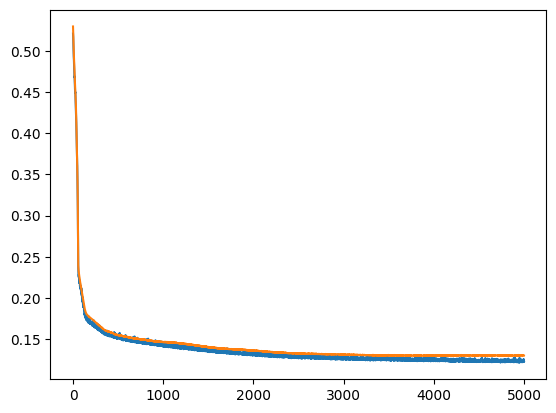

In [36]:
#Augmentation
#no keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

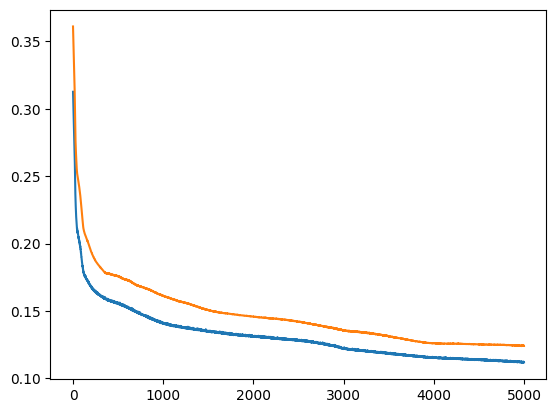

In [74]:
#Augmentation
#no keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

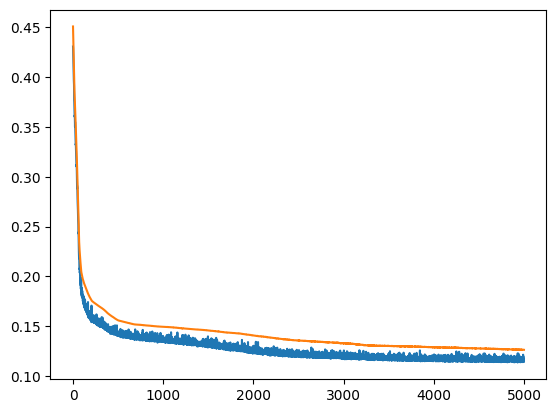

In [46]:
#no keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

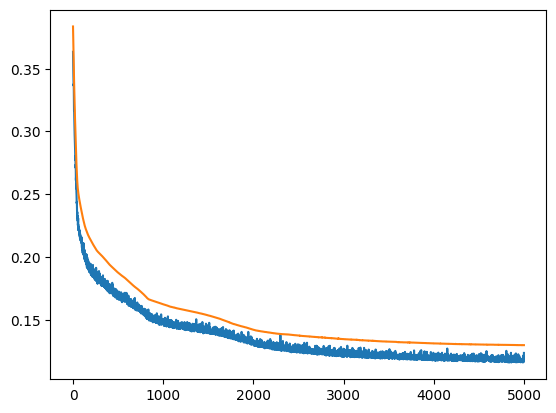

In [43]:
#no keeping one sample together
#4 layers each 8 neurons, custom loss, equal weights
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

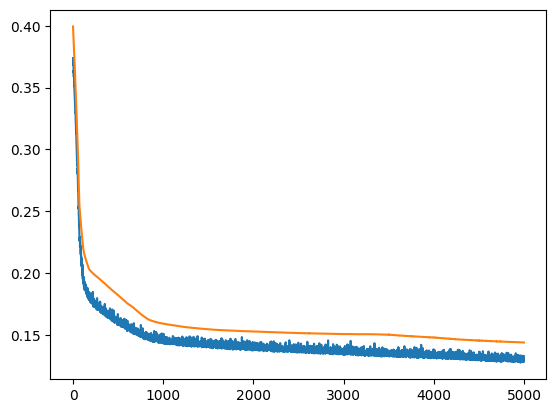

In [41]:
#no keeping one sample together
#4 layers each 8 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

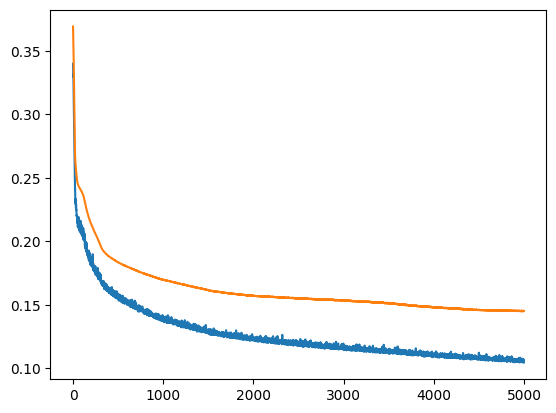

In [41]:
#no keeping one sample together
#4 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

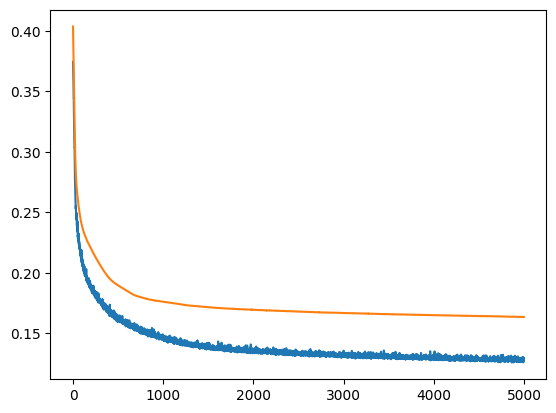

In [38]:
#no keeping one sample together
#2 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

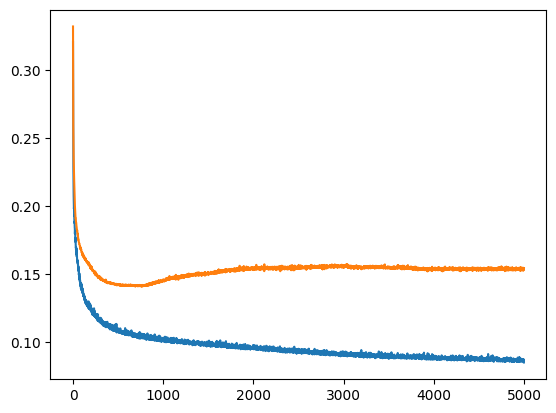

In [38]:
#no keeping one sample together
#3 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.001

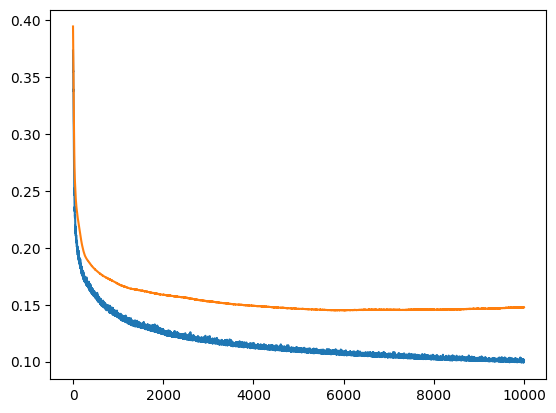

In [38]:
#no keeping one sample together
#3 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

## Test set

In [37]:
model.eval()
running_tloss = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    if i==0:
        out = outputs
        lab = labels
        res = abs(outputs-labels)
    res = torch.concat((res, abs(outputs-labels)), axis=0)
    lab = torch.concat((lab, labels), axis=0)
    out = torch.concat((out, outputs), axis=0)
    running_tloss += loss.item()
    
mean_loss = running_tloss/len(test_loader)

Consecutive inks from test set are in lab tensor (484 examples, 8 elements/coordinates):

In [38]:
lab

tensor([[-0.2516, -0.1372, -0.1700,  ..., -0.0737, -0.1979, -0.0951],
        [-0.2516, -0.1372, -0.1700,  ..., -0.0737, -0.1979, -0.0951],
        [ 0.2452, -0.1554, -0.1695,  ..., -0.0735, -0.1895, -0.0888],
        ...,
        [-0.1235, -0.0178, -0.1696,  ..., -0.0737, -0.1773, -0.0859],
        [-0.2362, -0.0918, -0.1699,  ..., -0.0738, -0.2123, -0.0750],
        [-0.2760, -0.1430, -0.1702,  ..., -0.0738, -0.2049, -0.0941]],
       device='cuda:0')

Predictions are in out tensor (484 examples, 8 elements/coordinates):

In [39]:
out

tensor([[-0.2592, -0.1482, -0.1666,  ..., -0.0732, -0.1884, -0.0842],
        [-0.2592, -0.1482, -0.1666,  ..., -0.0732, -0.1884, -0.0842],
        [-0.0865, -0.1442, -0.1660,  ..., -0.0889, -0.1887, -0.0855],
        ...,
        [-0.2321, -0.1292, -0.1692,  ..., -0.0777, -0.1829, -0.0926],
        [-0.2104, -0.1283, -0.1416,  ..., -0.0733, -0.0182, -0.0373],
        [-0.2094, -0.1296, -0.1661,  ..., -0.0800, -0.1371, -0.0834]],
       device='cuda:0', grad_fn=<CatBackward0>)

Absolute value of difference between true values (lab) and prediction (out) are stored in res tensor (484 examples, 8 elements/coordinates):

In [40]:
res

tensor([[7.5561e-03, 1.1004e-02, 3.3962e-03,  ..., 5.5908e-04, 9.5621e-03,
         1.0909e-02],
        [7.5561e-03, 1.1004e-02, 3.3962e-03,  ..., 5.5908e-04, 9.5621e-03,
         1.0909e-02],
        [3.3172e-01, 1.1215e-02, 3.5387e-03,  ..., 1.5415e-02, 7.8216e-04,
         3.2910e-03],
        ...,
        [1.0857e-01, 1.1149e-01, 3.1227e-04,  ..., 4.0282e-03, 5.5075e-03,
         6.7149e-03],
        [2.5862e-02, 3.6479e-02, 2.8307e-02,  ..., 5.0150e-04, 1.9404e-01,
         3.7704e-02],
        [6.6612e-02, 1.3416e-02, 4.0324e-03,  ..., 6.2062e-03, 6.7796e-02,
         1.0731e-02]], device='cuda:0', grad_fn=<CatBackward0>)

To calculate mean error on consecutive coordinates run:

In [41]:
torch.mean(res, axis=0) #augmentation

tensor([0.1260, 0.0847, 0.1139, 0.4470, 0.1957, 0.0537, 0.2355, 0.0441],
       device='cuda:0', grad_fn=<MeanBackward1>)

In [51]:
torch.mean(res, axis=0)

tensor([0.1438, 0.0755, 0.1315, 0.4444, 0.1952, 0.0479, 0.2338, 0.0492],
       device='cuda:0', grad_fn=<MeanBackward1>)

In [ ]:
Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb.

Later on we will modify loss function so that errors from coordinates will be weighted depending on the importance of chemical elements.

To calculate mean error on all coordinates run:

In [80]:
torch.mean(res)

tensor(0.1431, device='cuda:0', grad_fn=<MeanBackward0>)

In [56]:
torch.mean(res)

tensor(0.1353, device='cuda:0', grad_fn=<MeanBackward0>)

Below: some experiments, visualisations...

In [60]:
dim_nr = 0
selected_outputs = out[:, dim_nr].cpu().detach().numpy()
selected_labels = lab[:, dim_nr].cpu().detach().numpy()

In [61]:
#torch.max(out, axis=0)

(0.0, 4.0)

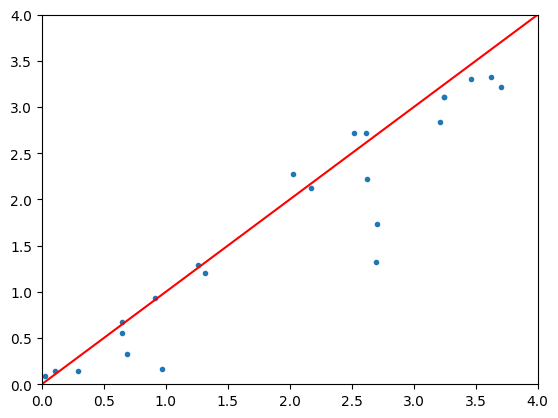

In [62]:
plt.plot(selected_labels, selected_outputs, '.')
plt.plot( [0,20],[0,20], 'red' )
plt.xlim(0, 4)
plt.ylim(0, 4)

In [52]:
torch.mean(res, 0)

tensor([0.1438, 0.0755, 0.1315, 0.4444, 0.1952, 0.0479, 0.2338, 0.0492],
       device='cuda:0', grad_fn=<MeanBackward1>)

In [64]:
mean_loss

0.13389697226871183

## Interpretability

...